# Genetic Algorithms

សៀវភៅកំណត់ត្រានេះ​ជា​ផ្នែក​មួយ​នៃ [កម្មវិធីសិក្សា AI សម្រាប់អ្នកចាប់ផ្តើម](http://github.com/microsoft/ai-for-beginners).


In [2]:
import random
import matplotlib.pyplot as plt
import numpy as np
import math
import time

## យុទ្ធសាស្ត្រមួយចំនួន

**អាល់ហ្គូរិធមិចេញពីមូលដ្ឋានអភិវឌ្ឍន៍** (GA) គឺផ្អែកលើ **វិធីសាស្ត្រអភិវឌ្ឍន៍** ទៅកាន់មនុស្សបច្ចេកវិទ្យាបញ្ញាសិប្បនិម្មិត ដែលវិធីសាស្ត្រនៃអភិវឌ្ឍន៍ប្រជាជនត្រូវបានប្រើសម្រាប់រកដំណោះស្រាយដ៏ល្អបំផុតសម្រាប់បញ្ហាមួយ។ វាត្រូវបានណែនាំឡើងក្នុងឆ្នាំ ១៩៧៥ ដោយ [John Henry Holland](https://en.wikipedia.org/wiki/John_Henry_Holland)។

អាល់ហ្គូរីធមិចេញពីមូលដ្ឋានអភិវឌ្ឍន៍ផ្អែកលើគំនិតដូចខាងក្រោម៖
* ដំណោះស្រាយត្រឹមត្រូវទៅលើបញ្ហា​អាចត្រូវបានបង្ហាញជារូបមន្ត **gene**
* **ការប្រារព្ធតម្កល់ផ្សំគ្នា** ឲ្យយើងអាចបញ្ចូលដំណោះស្រាយពីពីរចំនួនឲ្យបានដំណោះស្រាយថ្មីត្រឹមត្រូវ
* **ការជ្រើសរើស** ត្រូវបានប្រើសម្រាប់ជ្រើសរើសដំណោះស្រាយល្អបំផុតដោយប្រើមុខងារ **fitness**
* **ការប្រែក្លាយ** ត្រូវបានណែនាំដើម្បីបំភាន់ដំណោះស្រាយបញ្ចូលនិងយកយើងចេញពីអប្បបរមាទីតាំង

បើអ្នកចង់អនុវត្តអាល់ហ្គូរិធមិចេញពីមូលដ្ឋានអភិវឌ្ឍន៍ អ្នកត្រូវការដូចខាងក្រោម៖

 * រកវិធីសាស្ត្រសម្រាប់កូដដំណោះស្រាយរបស់បញ្ហាយើងដោយប្រើ **gene** $g\in\Gamma$
 * លើកម្រិត gene $\Gamma$ យើងត្រូវកំណត់ **មុខងារ fitness** $\mathrm{fit}: \Gamma\to\mathbb{R}$. តម្លៃមុខងារតូចជាងនឹងផ្ដល់ដំណោះស្រាយល្អជាង។
 * កំណត់គ្រឿងម៉ាស៊ីន **crossover** សម្រាប់បញ្ចូល gene ពីរចូលជាមួយគ្នា ដើម្បីទទួលបានដំណោះស្រាយថ្មី $\mathrm{crossover}: \Gamma^2\to\Gamma$។
 * កំណត់គ្រឿងម៉ាស៊ីន **mutation** $\mathrm{mutate}: \Gamma\to\Gamma$។
នៅក្នុងករណីជាច្រើន ការប្រារព្ធតម្កល់ផ្សំគ្នា និងការប្រែក្លាយគឺជាអាល់ហ្គូរីធមិដ៏សាមញ្ញសម្រាប់ដំណើរការមូលដ្ឋាន gene ជាជួរលេខ ឬវ៉ិចទ័រប៊ីត។

ការអនុវត្តជាក់លាក់នៃអាល់ហ្គូរិធមិចេញពីមូលដ្ឋានអភិវឌ្ឍន៍អាចខុសគ្នាច្រើន ក្នុងករណីផ្សេងៗ ប៉ុន្តែរចនាសម្ព័ន្ធទូទៅគឺដូចតទៅ៖

1. ជ្រើសរើសប្រជាជនដំបូង $G\subset\Gamma$
2. ជ្រើសរើសចៃដន្យមួយនៅក្នុងប្រតិបត្តិការដែលនឹងអនុវត្តនៅជំហាននេះ៖ ការប្រារព្ធតម្កល់ផ្សំគ្នា ឬ ការប្រែក្លាយ
3. **ការប្រារព្ធតម្កល់ផ្សំគ្នា**៖
  * ជ្រើសរើស gene ពីរចៃដន្យ $g_1, g_2 \in G$
  * គណនាការប្រារព្ធតម្កល់ផ្សំគ្នា $g=\mathrm{crossover}(g_1,g_2)$
  * ប្រសិនបើ $\mathrm{fit}(g)<\mathrm{fit}(g_1)$ ឬ $\mathrm{fit}(g)<\mathrm{fit}(g_2)$ - ប្តូរ gene តាមលំដាប់នៅក្នុងប្រជាជនដោយ $g$។
4. **ការប្រែក្លាយ** - ជ្រើសរើស gene តែមួយ $g\in G$ ហើយប្តូរតាម $\mathrm{mutate}(g)$
5. ធ្វើឡើងវិញពីជំហាន 2 រហូតដល់យើងទទួលបានតម្លៃតូចគ្រប់គ្រាន់នៃ $\mathrm{fit}$ ឬរហូតដល់ដល់ព្រំដែននៃចំនួនជំហាន

ភារកិច្ចដែលភាគច្រើនត្រូវបានដោះស្រាយដោយ GA៖
1. ការបង្រួមម៉ោងផែនការ
1. ការវេចខ្ចប់ល្អបំផុត
1. ការកាត់ល្អបំផុត
1. ល្បឿនដំណើរការជម្រះការស្វែងរកគ្រប់គ្រាន់


## ប្រធានបទទី 1៖ ការចែកភាគទានរបស់សំភារៈទ្រព្យមួយយ៉ាងស្មើភាគ

**ភារកិច្ច**:  
មនុស្សពីរនាក់បានរកឃើញសំភារៈទ្រព្យមួយដែលមានផ្កាយអង្កត់ដែកចំនួនខុសគ្នា (ហើយទំនងជាតម្លៃផ្ទៀងផ្ទាត់ខុសគ្នា) ។ ពួកគេចាំបាច់ត្រូវចែកភាគទ្រព្យនេះជាពីរផ្នែក ដោយវិធីសាស្រ្តដែលខុសគ្នានៃតម្លៃគឺ 0 (ឬតិចបំផុត) ។

**និយមន័យផ្លូវការជា**:  
យើងមានសំណុំចំនួន $S$។ យើងត្រូវចែកវាជាពីរសំណុំតួ $S_1$ និង $S_2$ ដូចដែល $$\left|\sum_{i\in S_1}i - \sum_{j\in S_2}j\right|\to\min$$ ហើយ $S_1\cup S_2=S$, $S_1\cap S_2=\emptyset$។

មុនដំបូង អនុវត្តន៍កំណត់សំណុំ $S$:


In [3]:
N = 200
S = np.array([random.randint(1,10000) for _ in range(N)])
print(S)

[8344 2197 9335 3131 5863 9429 3818 9791   15 5455 1396 9538 4872 6549
 8587 5986 6021 9764 8102 5083 5739 7684 8498 3007 6599  820 7490 2372
 9370 5235 3525 3154  859 1906 8159 3950 2173 2988 2050  349 8713 2284
 4177 6033 1651 9176 5049 8201  171 5081 1216 3756 4711 2757 7738 1272
 5650 6584 5395 9004 7797  969 8104 1283 1392 4001 5768  445  274  256
 8239 8015 4381 9021 1189 8879 1411 3539 6526 8011  136 7230 2332  451
 5702 2989 4320 2446 9578 8486 4027 2410 9588 8981 2177 1493 3232 9151
 4835 5594 6859 8394  369 3200  126 4259 2283 7755 2014 2458 8327 8082
 7413 7622 1206 5533 8751 3495 5868 8472 6850 3958 3149 4672 4810 6274
 4700 6134 4627 4616 6656 9949  884 2256 7419 1926 7973 5319 5967 9158
 3823 7697 9466 5675 5412 9784 5426 8209 3421 1136 6047 4429 8001 4417
 1381  722 7350 6018 6235 7860 5853 7660 5937 6242    1 9552 3971 8302
 2633 9227 7283  154 8599 4269 9392 8539 1630  368 2409 9351 3838 9814
 6186 5743 5083 1325 1610  779 3643 3262 5768 8725  961 4611 6310 4788
 1648 

ចូរយើងបំលែងដំណោះស្រាយរាល់ករណីនៃបញ្ហាទៅជាវ៉ិចទ័រប៊ីណារី $B\in\{0,1\}^N$ ដែលលេខនៅទីតាំង $i$ បង្ហាញថា គឺសម្រាប់កំណត់នៅក្នុងសំណុំណាមួយ ($S_1$ ឬ $S_2$) ដែលលេខទី $i$ ក្នុងសំណុំដើម $S$ ស្ថិត។ មុខងារ `generate` នឹងបង្កើតវ៉ិចទ័រប៊ីណារីព្រមានោះ។


In [5]:
def generate(S):
    return np.array([random.randint(0,1) for _ in S])

b = generate(S)
print(b)

[1 0 0 1 1 1 1 1 0 1 1 1 0 0 1 0 1 1 1 0 0 1 1 0 1 1 0 0 1 0 1 0 1 0 1 1 1
 0 1 1 1 0 1 0 0 1 0 0 1 1 0 1 0 1 1 0 0 1 0 0 0 1 1 0 1 1 0 0 0 0 1 0 1 0
 1 0 0 0 0 0 1 1 0 1 0 0 1 0 1 0 0 1 1 0 0 1 1 1 0 0 1 1 0 1 1 0 0 0 0 1 1
 1 0 1 0 0 1 1 1 1 1 1 1 1 0 1 0 1 1 1 1 1 1 0 1 0 1 0 1 0 0 1 1 1 0 0 1 1
 0 1 1 0 1 1 0 0 0 1 1 0 0 0 0 0 0 0 0 1 1 0 1 1 1 0 0 1 1 0 1 1 0 0 1 1 0
 0 0 0 1 0 1 1 0 1 1 0 1 0 0 0]


ឥឡូវនេះយើងមកកំណត់អនុគមន៍ `fit` ដែលគណនាថ្លៃ "ការចំណាយ" នៃដំណោះស្រាយ។ វានឹងជារបៀបគ្រប់គ្រាន់រវាងផលបូកនៃសំណុំពីរប្រភេទ $S_1$ និង $S_2$:


In [6]:
def fit(B,S=S):
    c1 = (B*S).sum()
    c2 = ((1-B)*S).sum()
    return abs(c1-c2)

fit(b)

133784

ឥឡូវនេះយើងត្រូវកំណត់មុខងារសម្រាប់ការបន្សុទ្ធ និងការជម្លុះ៖
* សម្រាប់ការបន្សុទ្ធ យើងនឹងជ្រើសរើសប៊ីតចៃដន្យមួយ ហើយបដិសេធវា (ផ្លាស់ពី 0 ទៅ 1 និងផ្ទុយគ្នា)
* សម្រាប់ការជម្លុះ យើងនឹងយកប៊ីតខ្លះពីវ៉ិចទ័រមួយ ហើយយកប៊ីតខ្លះពីវ៉ិចទ័រមួយផ្សេងទៀត។ យើងនឹងប្រើមុខងារ `generate` ដូចគ្នា ដើម្បីជ្រើសរើសយ៉ាងចៃដន្យ មួយចំនួនប៊ីតណា វិញទៅយកពីម៉ាសខាងណាមួយ។


In [7]:
def mutate(b):
    x = b.copy()
    i = random.randint(0,len(b)-1)
    x[i] = 1-x[i]
    return x

def xover(b1,b2):
    x = generate(b1)
    return b1*x+b2*(1-x)

ចង់បង្កើតប្រជាជនដំបូងនៃដំណោះស្រាយ $P$ ដែលមានទំហំ `pop_size`:


In [8]:
pop_size = 30
P = [generate(S) for _ in range(pop_size)]

ឥឡូវនេះ, មុខងារ​សំខាន់​ដើម្បីអនុវត្ត​ការវិវឌ្ឍន៍។ `n` គឺជាចំនួន​ជំហាននៃការវិវឌ្ឍន៍ ដែលត្រូវអនុវត្ត។ នៅក្នុងគ្រប់ជំហាន៖
* ជាមួយនឹងប្រហោងនៃ 30% យើងអនុវត្តការបម្លែងមូត និងជំនួសធាតុដែលមាន `fit` ហើយអ χει្យពីរាម។  
* ជាមួយនឹងប្រហោងនៃ 70% យើងអនុវត្តការប្តូរចំណែក

មុខងារនេះ ត្រលប់វិញលទ្ធផលល្អបំផុត (gene ដែលពាក់ព័ន្ធនឹងលទ្ធផលល្អបំផុត) និងប្រវត្តិនៃមុខងារ fit តិចបំផុតក្នុងប្រជាជននៅក្នុងគ្រប់ជំហាន។


In [9]:
def evolve(P,S=S,n=2000):
    res = []
    for _ in range(n):
        f = min([fit(b) for b in P])
        res.append(f)
        if f==0:
            break
        if random.randint(1,10)<3:
            i = random.randint(0,len(P)-1)
            b = mutate(P[i])
            i = np.argmax([fit(z) for z in P])
            P[i] = b
        else:
            i = random.randint(0,len(P)-1)
            j = random.randint(0,len(P)-1)
            b = xover(P[i],P[j])
            if fit(b)<fit(P[i]):
                P[i]=b
            elif fit(b)<fit(P[j]):
                P[j]=b
            else:
                pass
    i = np.argmin([fit(b) for b in P])
    return (P[i],res)

(s,hist) = evolve(P)
print(s,fit(s))

[0 0 0 1 1 0 0 0 0 1 1 1 0 1 0 0 0 1 0 1 0 1 0 1 0 1 1 0 0 0 0 0 1 0 1 1 0
 0 0 0 1 1 0 0 1 0 0 0 0 0 1 0 0 1 1 1 1 1 1 1 0 1 1 0 1 1 1 1 1 0 1 0 0 0
 0 1 1 1 0 1 0 1 1 1 1 1 0 0 0 1 1 0 1 0 0 1 0 0 1 1 1 1 1 1 1 1 0 1 0 1 1
 0 1 1 0 0 0 0 1 1 1 1 0 1 0 0 1 0 1 1 1 0 1 0 0 0 0 0 0 1 1 0 0 0 1 1 0 0
 1 0 1 1 1 1 1 0 1 0 1 0 1 1 1 0 0 0 1 1 0 0 0 0 0 0 1 1 1 0 1 0 0 0 1 0 1
 0 1 0 1 0 0 1 1 1 0 1 1 0 0 1] 4


អ្នកអាចមើលឃើញថា យើងបានគ្រប់គ្រងដើម្បីកាត់បន្ថយមុខងារ `fit` ឲ្យតិចបំផុត! នេះជាតារាងដែលបង្ហាញពីរបៀបដែលមុខងារ `fit` សម្រាប់ប្រជាជនទាំងមូលធ្វើការទៅក្នុងអំឡុងពេលនៃដំណើរការ។


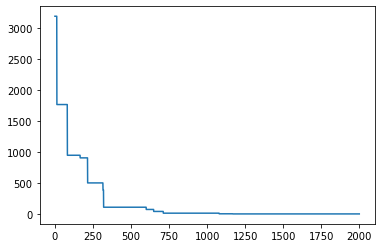

In [10]:
plt.plot(hist)
plt.show()

## បញ្ហា 2: បញ្ហា N Queens

**ការងារ**:  
អ្នកត្រូវតែដាក់រាជនី $N$ លើក្តារតាសូដមួយដែលមានទំហំ $N\times N$ ដោយរបៀបដែលពួកវាមិនធ្វើឲ្យមានការវាយប្រហារជាមួយគ្នាទេ។

ដំបូង សូមដោះស្រាយបញ្ហាមួយទាល់តែគ្មានអាល់ហ្គរីធម៍ជីនេតិច ដោយប្រើការស្វែងរកពេញលេញ។ យើងអាចតំណាងស្ថានភាពនៃក្តារតាសូដោយបញ្ជី $L$ ដែលលេខទី $i$ ក្នុងបញ្ជីគឺជាទីតាំងដេកនៃរាជនីនៅជាន់ទី $i$។ វាពិតជាដូចជាលេចធ្លោក្នុងចិត្តថា ដំណោះស្រាយមួយៗនឹងមានរាជនីតែមួយក្នុងមួយជាន់ ហើយគ្រប់ជាន់នឹងមានរាជនីមួយ។

គោលបំណងរបស់យើងគឺស្វែងរកដំណោះស្រាយដំបូងនៃបញ្ហា បន្ទាប់ពីវាអាចបញ្ឈប់ការស្វែងរក។ អ្នកអាចបន្ថែមមុខងារនេះឲ្យបង្កើតទីតាំងរាជនីរាល់ករណីដែលអាចធ្វើបាន។


In [11]:
N = 8

def checkbeats(i_new,j_new,l):
    for i,j in enumerate(l,start=1):
        if j==j_new:
            return False
        else:
            if abs(j-j_new) == i_new-i:
                return False
    return True

def nqueens(l,N=8,disp=True):
    if len(l)==N:
        if disp: print(l)
        return True
    else:
        for j in range(1,N+1):
            if checkbeats(len(l)+1,j,l):
                l.append(j)
                if nqueens(l,N,disp): return True
                else: l.pop()
        return False
            
nqueens([],8)


[1, 5, 8, 6, 3, 7, 2, 4]


True

Now let's measure how long does it take to get a solution for 20-queens problem:

In [12]:
%timeit nqueens([],20,False)

10.6 s ± 2.17 s per loop (mean ± std. dev. of 7 runs, 1 loop each)


ឥឡូវនេះ យើងនឹងដោះស្រាយបញ្ហាដដែលនេះដោយប្រើអាល់ហ្គរីធម៍ជេនេទិក។ ដំណោះស្រាយនេះបានចេញពី [អត្ថបទប្លុកនេះ](https://kushalvyas.github.io/gen_8Q.html).

យើងនឹងតំណាងឲ្យគ្រប់ដំណោះស្រាយដោយបញ្ជីដូចគ្នាមួយដែលមានប្រវែង $N$, ហើយជាអនុគមន៍ `fit` យើងនឹងយកចំនួនរាជនីដែលវាយប្រហារគ្នា:


In [13]:
def fit(L):
    x=0
    for i1,j1 in enumerate(L,1):
        for i2,j2 in enumerate(L,1):
            if i2>i1:
                if j2==j1 or (abs(j2-j1)==i2-i1): x+=1
    return x

ដោយសារ​ការ​គណនា​មុខងារ​សមត្ថភាព (fitness function) ត្រូវ​ចំណាយ​ពេល​ច្រើន យើង​នឹង​ទុក​ដំណោះស្រាយ​នីមួយៗ​នៅក្នុង​ប្រជាជន ដោយ​បញ្ចូល​តម្លៃ​នៃ​មុខងារ​សមត្ថភាព​ផងដែរ។ តោះ​យើង​បង្កើត​ប្រជាជន​ដំបូង៖


In [14]:
def generate_one(N):
    x = np.arange(1,N+1)
    np.random.shuffle(x)
    return (x,fit(x))

def generate(N,NP):
    return [generate_one(N) for _ in range(NP)]

generate(8,5)

[(array([2, 3, 8, 7, 5, 4, 1, 6]), 4),
 (array([3, 4, 5, 1, 2, 8, 6, 7]), 8),
 (array([1, 3, 7, 4, 5, 8, 6, 2]), 6),
 (array([1, 5, 4, 6, 8, 3, 7, 2]), 4),
 (array([3, 5, 7, 1, 8, 6, 4, 2]), 3)]

ឥឡូវនេះយើងត្រូវកំណត់អនុគមន៍ mutation និង crossover។ Crossover នឹងរួមបញ្ចូលជីនពីរជាមួយគ្នា ដោយបំបែកពួកវានៅចំណុចចៃដន្យមួយ ហើយភ្ជាប់ផ្នែកពីរពីជីនផ្សេងៗគ្នាឱ្យរួមគ្នា។


In [15]:
def mutate(G):
    x=random.randint(0,len(G)-1)
    G[x]=random.randint(1,len(G))
    return G
    
def xover(G1,G2):
    x=random.randint(0,len(G1))
    return np.concatenate((G1[:x],G2[x:]))

xover([1,2,3,4],[5,6,7,8])

array([1, 2, 7, 8])

យើងនឹងពង្រឹងដំណើរការជ្រើសរើសជីន ដោយជ្រើសយកជីនច្រើនជាងមុន ដែលមានអនុគមន៍សមភាពល្អប្រសើរជាង។ ឱកាសនៃការជ្រើសរើសជីនមួយនឹងអាស្រ័យលើអនុគមន៍សមភាព:


In [17]:
def choose_rand(P):
    N=len(P[0][0])
    mf = N*(N-1)//2 # max fitness fn
    z = [mf-x[1] for x in P]
    tf = sum(z) # total fitness
    w = [x/tf for x in z]
    p = np.random.choice(len(P),2,False,p=w)
    return p[0],p[1]

def choose(P):
    def ch(w):
        p=[]
        while p==[]:
            r = random.random()
            p = [i for i,x in enumerate(P) if x[1]>=r]
        return random.choice(p)
    N=len(P[0][0])
    mf = N*(N-1)//2 # max fitness fn
    z = [mf-x[1] for x in P]
    tf = sum(z) # total fitness
    w = [x/tf for x in z]
    p1=p2=0
    while p1==p2:
        p1 = ch(w)
        p2 = ch(w)
    return p1,p2

ឥឡូវ​យើង​មក​កំណត់​ចរន្ត​​អភិវឌ្ឍន៍​សំខាន់។ យើង​នឹង​ធ្វើ​ឱ្យ​តុល្យភាព​តិចតួច​ខុសពី​ឧទាហរណ៍​មុន ដើម្បី​បង្ហាញ​ថា​អ្នក​អាច​ច្នៃ​ប្រឌិត​បាន។ យើង​នឹង​ធ្វើ​លំនាំ​ម្តងៗ​រហូត​ដល់​ទទួល​បាន​ដំណោះ​ស្រាយ​ល្អឥតខ្ចោះ (fitness function=0), ហើយ​នៅលើក​មួយៗ យើង​នឹង​យក​ជំនាន់​បច្ចុប្បន្ន ហើយ​បង្កើត​ជំនាន់​ថ្មី​ដែល​មាន​ទំហំ​ដូចគ្នា។ នេះ​កើតឡើង​ដោយប្រើ​មុខងារ `nxgeneration` ដោយ​អនុវត្ត​ជំហាន​ដូច​ខាងក្រោម៖

1. ដោះចោល​ដំណោះស្រាយ​ដែល​ខ្សោយបំផុត - មាន​មុខងារ `discard_unfit` ដែល​ធ្វើ​ការ​នេះ
1. បន្ថែម​ដំណោះស្រាយ​ចៃដន្យ​បន្ថែម​ចូលទៅ​ក្នុង​ជំនាន់
1. បំពេញ​ជំនាន់​ថ្មី​ដែល​មាន​ទំហំ `gen_size` ដោយ​អនុ​វត្ត​ជំហាន​ដូច​ខាងក្រោម​សម្រាប់​គ្រប់​ជីន​ថ្មី​មួយៗ៖
    - ជ្រើសយក​ជីន​ចៃដន្យពីរ​ដុំ ដោយ​ប្រភាព​សមាមាត្រ​ទៅ​នឹង fitness function
    - គណនា crossover
    - អនុវត្ត mutation ជាមួយ​ប្រភាព `mutation_prob`


In [20]:
mutation_prob = 0.1

def discard_unfit(P):
    P.sort(key=lambda x:x[1])
    return P[:len(P)//3]

def nxgeneration(P):
    gen_size=len(P)
    P = discard_unfit(P)
    P.extend(generate(len(P[0][0]),3))
    new_gen = []
    for _ in range(gen_size):
        p1,p2 = choose_rand(P)
        n = xover(P[p1][0],P[p2][0])
        if random.random()<mutation_prob:
            n=mutate(n)
        nf = fit(n)
        new_gen.append((n,nf))
        '''
        if (nf<=P[p1][1]) or (nf<=P[p2][1]):
            new_gen.append((n,nf))
        elif (P[p1][1]<P[p2][1]):
            new_gen.append(P[p1])
        else:
            new_gen.append(P[p2])
        '''
    return new_gen
    
def genetic(N,pop_size=100):
    P = generate(N,pop_size)
    mf = min([x[1] for x in P])
    n=0
    while mf>0:
        #print("Generation {0}, fit={1}".format(n,mf))
        n+=1
        mf = min([x[1] for x in P])
        P = nxgeneration(P)
    mi = np.argmin([x[1] for x in P])
    return P[mi]

genetic(8)

(array([4, 7, 5, 3, 1, 6, 8, 2]), 0)

គួរឱ្យចាប់អារម្មណ៍ថា នៅភាគច្រើនពេល យើងអាចរកឃើញដំណោះស្រាយបានយ៉ាងឆាប់រហ័ស ប៉ុន្តែនៅក្នុងករណីមួយចំនួនដែលកើតឡើងតិច ការទាក់ទងដើម្បីធ្វើអុបទីម៉ីសេសិនអាចបញ្ចប់នៅចំណុចទាបក្នុងតំបន់ (local minimum) ហើយដំណើរការនោះត្រូវរអើរយូរជាងសាមញ្ញ។ វាសំខាន់ក្នុងការយកចិត្តទុកដាក់ពេលដែលអ្នកវាស់ពេលមធ្យម៖ នៅភាគច្រើនករណី អាល់ហ្គរីធឹមជេនេទិចនឹងរហ័សជាងការស្វែងរកពេញលេញ ប៉ុន្តែក្នុងករណីខ្លះវាអាចចំណាយពេលយូរជាង។ ដើម្បីដោះស្រាយបញ្ហានេះ ជាញឹកញាប់វាមានប្រយោជន៍ក្នុងការគីតដល់ចំនួនជំនាន់ដែលត្រូវពិចារណា ហើយប្រសិនបើយើងមិនអាចរកឃើញដំណោះស្រាយបាន យើងអាចចាប់ផ្តើមឡើងវិញពីដើម។


In [19]:
%timeit genetic(10)

The slowest run took 18.71 times longer than the fastest. This could mean that an intermediate result is being cached.
26.4 s ± 28.7 s per loop (mean ± std. dev. of 7 runs, 1 loop each)


---

<!-- CO-OP TRANSLATOR DISCLAIMER START -->
**Disclaimer**:
ឯកសារនេះត្រូវបានបកប្រែដោយប្រើសេវាកម្មបកប្រែ AI [Co-op Translator](https://github.com/Azure/co-op-translator). ខណៈពេលយើងខំប្រឹងប្រែងដើម្បីភាពត្រឹមត្រូវ សូមយល់ព្រមថាការបកប្រែដោយស្វ័យប្រវត្តិអាចមានកំហុស ឬភាពមិនត្រឹមត្រូវ។ ឯកសារដើមក្នុងភាសាដើមគួរត្រូវបានចាត់ទុកជា​ប្រភពដែលមានអាជ្ញាធរ និងជាឯកសារយោង។ សម្រាប់ព័ត៌មានសំខាន់ យើងណែនាំឲ្យប្រើប្រាស់ការបកប្រែដោយអ្នកបកប្រែជាមនុស្សជំនាញ។ យើងមិនទទួលខុសត្រូវចំពោះការយល់ច្រឡំ ឬការបកស្រាយខុសណាមួយដែលកើតឡើងពីការប្រើប្រាស់ការបកប្រែនេះទេ។
<!-- CO-OP TRANSLATOR DISCLAIMER END -->
